In [1]:
#setup 

import torch
import random
import matplotlib.pyplot as plt
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid
import os


In [2]:
if not os.path.exists('./UNet_img'):
    os.mkdir('./UNet_img')
    
print ("setup done")

setup done


In [3]:
#helper functions
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

In [4]:
#hyperparameters
num_epochs = 10 #each epoch has a runtime of approx. 4 min
batch_size = 128
learning_rate = 1e-3

markdown the data set cell that will not be used.
user must set USE_XRAY_VAL in Xray data set to true or false depeinding on if the run is for train or validation

In [6]:
#Chest xray data loading and data set

img_transform = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.Grayscale(num_output_channels=1),  # ensure 1 channel like FashionMINST
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

xray_train_dataset = datasets.ImageFolder('./chest_xray/train', transform=img_transform)
print("xray Training samples:", len(xray_train_dataset))
train_dataloader = DataLoader(xray_train_dataset, batch_size=batch_size, shuffle=True)
print("Number of training batches:", len(train_dataloader))

xray_val_dataset = datasets.ImageFolder('./chest_xray/val', transform=img_transform)
print("xray Validation samples:", len(xray_val_dataset))
val_dataloader = DataLoader(xray_val_dataset, batch_size=batch_size, shuffle=True)
print("Number of validation batches:", len(val_dataloader))

xray Training samples: 5216
Number of training batches: 41
xray Validation samples: 16
Number of validation batches: 1


In [7]:
#add noise to the image
def add_noise(img, sigma=0.2):
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, -1., 1.)  # keep same range
    return noisy_img

In [8]:
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()

        # -------- Encoder --------
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1),    # 32 x 128 x 128
            nn.ReLU(True),
            nn.Conv2d(32, 32, 3, stride=1, padding=1),   # 32 x 128 x 128
            nn.ReLU(True)
        )
        self.pool1 = nn.MaxPool2d(2, stride=2)           # 32 x 64 x 64

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=1, padding=1),   # 64 x 64 x 64
            nn.ReLU(True),
            nn.Conv2d(64, 64, 3, stride=1, padding=1),   # 64 x 64 x 64
            nn.ReLU(True)
        )
        self.pool2 = nn.MaxPool2d(2, stride=2)           # 64 x 32 x 32

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=1, padding=1),  # 128 x 32 x 32
            nn.ReLU(True),
            nn.Conv2d(128, 128, 3, stride=1, padding=1), # 128 x 32 x 32
            nn.ReLU(True)
        )

        # -------- Decoder --------
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)  # 64 x 64 x 64
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, 3, stride=1, padding=1),   # concat skip from enc2
            nn.ReLU(True),
            nn.Conv2d(64, 64, 3, stride=1, padding=1),
            nn.ReLU(True)
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)   # 32 x 128 x 128
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, stride=1, padding=1),    # concat skip from enc1
            nn.ReLU(True),
            nn.Conv2d(32, 32, 3, stride=1, padding=1),
            nn.ReLU(True)
        )

        self.final_conv = nn.Sequential(
            nn.Conv2d(32, 1, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x1 = self.enc1(x)
        p1 = self.pool1(x1)

        x2 = self.enc2(p1)
        p2 = self.pool2(x2)

        b = self.bottleneck(p2)

        d2 = self.up2(b)
        d2 = torch.cat([d2, x2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, x1], dim=1)
        d1 = self.dec1(d1)

        out = self.final_conv(d1)
        return out

print("model defined")

model defined


In [9]:
#Model and optimizer
model = autoencoder()

# load model if exists
if os.path.exists("unet_model.pth"):
    data = torch.load("unet_model.pth")

    model.load_state_dict(data['model_state_dict'])
    unet_val_loss = data['unet_val_loss']

    print("Loaded previous model weights")
    print(f"Loaded unet_val_loss: {unet_val_loss:.4f}")

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=1e-5)
    optimizer.load_state_dict(data['optimizer'])
    #redusing the learning rate for a run when oscialltion is seen in a prior run
    # for param_group in optimizer.param_groups: 
    #     param_group['lr'] = 1e-4

else:
    unet_val_loss = float('inf') #infinity value for initial unet val so that any val loss in first run is less than it

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=1e-5)
    
criterion = nn.MSELoss()

In [10]:
#detect the last run number from UNet_img folder so that images saved in it are based on run number and repective epoch within the run.
save_path = "./UNet_img"

existing_files = os.listdir(save_path)

run_ids = []

for f in existing_files:
    if "run" in f:
        try:
            run_num = int(f.split("run_")[1].split("_")[0])
            run_ids.append(run_num)
        except:
            pass

run_id = max(run_ids) + 1 if run_ids else 1

print(f"Starting Run {run_id}")

Starting Run 1


In [11]:
#save locally a grid of size 9X8 where first 3 rows are original images, later 3 rows are their respective noisy versions, later 3 rows are their respective reconstruced versions
#images are randomly selected from same batch
train=True #inital value, will be updated in the training loop to differentiate between training and validation images when saving the grid.
def save_comparison_grid(img, noisy_img, output, epoch, save_path="./UNet_img"):
    
    num_cols = 8
    num_imgs = num_cols * 3   #24 images → 3 rows per category

    #random selection (same indices for all 3 types)
    indices = torch.randperm(img.size(0))[:num_imgs]

    orig_imgs = img[indices]
    noisy_imgs = noisy_img[indices]
    recon_imgs = output[indices]

    #convert to [0,1]
    orig_imgs = to_img(orig_imgs)
    noisy_imgs = to_img(noisy_imgs)
    recon_imgs = to_img(recon_imgs)

    #stack: orig below it is noisy below it is recon
    grid_imgs = torch.cat([orig_imgs, noisy_imgs, recon_imgs], dim=0)

    #create grid
    grid = make_grid(grid_imgs, nrow=num_cols)

    #save
    if train:
        save_image(grid, f"{save_path}/training_run_{run_id}_epoch_{epoch}.png")
    if not train:
        save_image(grid, f"{save_path}/validation_run_{run_id}_epoch_{epoch}.png") 
    return grid

In [12]:
#saving the loss of cuurrent run so that in next run it gets appended to the new loss in the loss curve in order to show a representative learning flow
train_loss_file = "losses.pt"
val_loss_file = "val_losses.pt"
#load train losses
if os.path.exists(train_loss_file):
    train_losses = torch.load(train_loss_file)
    print(f"Loaded previous losses: {len(train_losses)} points")
else:
    train_losses = [] 
# Load validation losses 
if os.path.exists(val_loss_file):
    val_losses = torch.load(val_loss_file)
    print(f"Loaded val losses: {len(val_losses)} points")
else:
    val_losses = []


Training 


Epoch [1/10], Loss: 0.0453


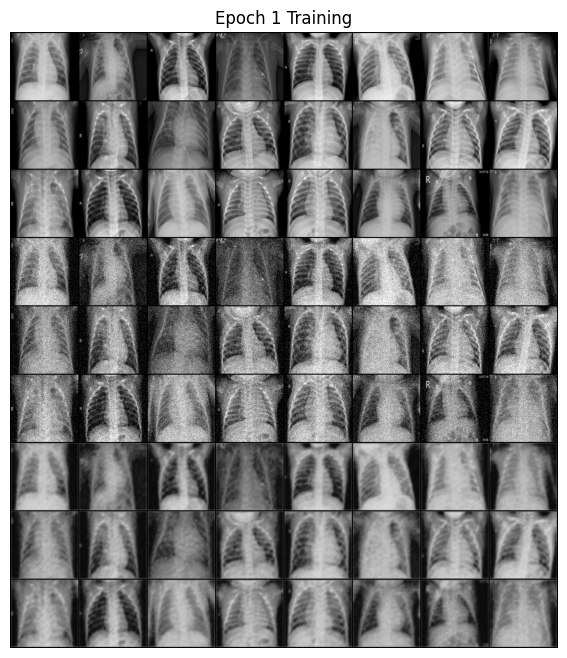

Validation 
Epoch [1/10], val_Loss: 0.0090


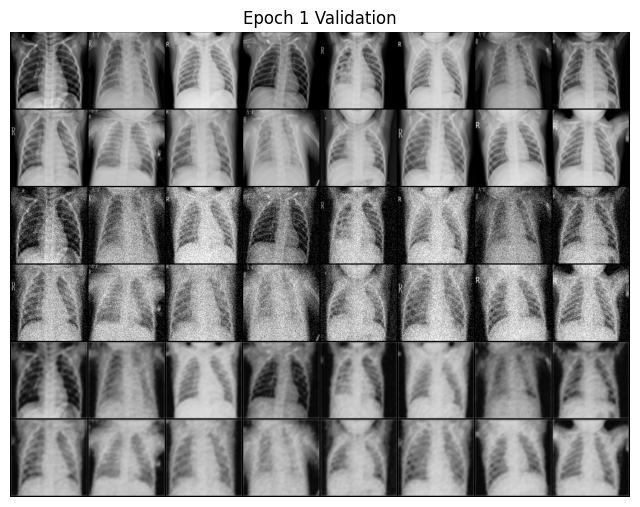

 Saved unet model at epoch 1 with val loss 0.0090
Training 
Epoch [2/10], Loss: 0.0072
Validation 
Epoch [2/10], val_Loss: 0.0058
 Saved unet model at epoch 2 with val loss 0.0058
Training 
Epoch [3/10], Loss: 0.0059
Validation 
Epoch [3/10], val_Loss: 0.0048
 Saved unet model at epoch 3 with val loss 0.0048
Training 
Epoch [4/10], Loss: 0.0057
Validation 
Epoch [4/10], val_Loss: 0.0044
 Saved unet model at epoch 4 with val loss 0.0044
Training 
Epoch [5/10], Loss: 0.0048
Validation 
Epoch [5/10], val_Loss: 0.0043
 Saved unet model at epoch 5 with val loss 0.0043
Training 
Epoch [6/10], Loss: 0.0048
Validation 
Epoch [6/10], val_Loss: 0.0041
 Saved unet model at epoch 6 with val loss 0.0041
Training 
Epoch [7/10], Loss: 0.0048
Validation 
Epoch [7/10], val_Loss: 0.0041
Training 
Epoch [8/10], Loss: 0.0045
Validation 
Epoch [8/10], val_Loss: 0.0043
Training 
Epoch [9/10], Loss: 0.0044
Validation 
Epoch [9/10], val_Loss: 0.0043
Training 
Epoch [10/10], Loss: 0.0044


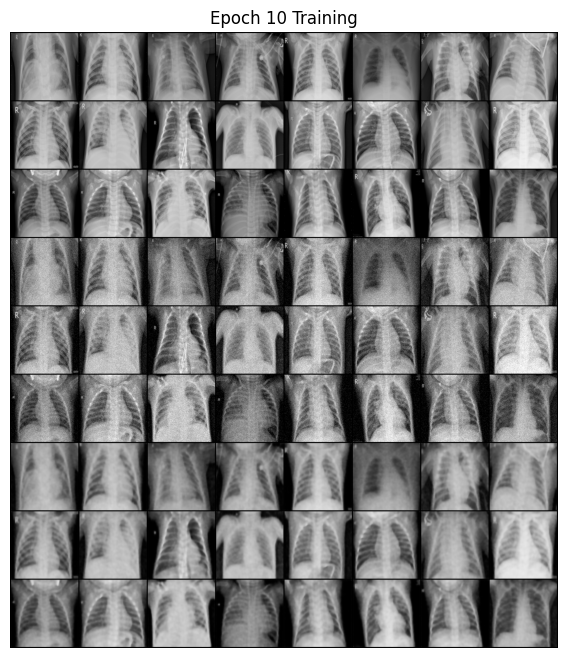

Validation 
Epoch [10/10], val_Loss: 0.0038


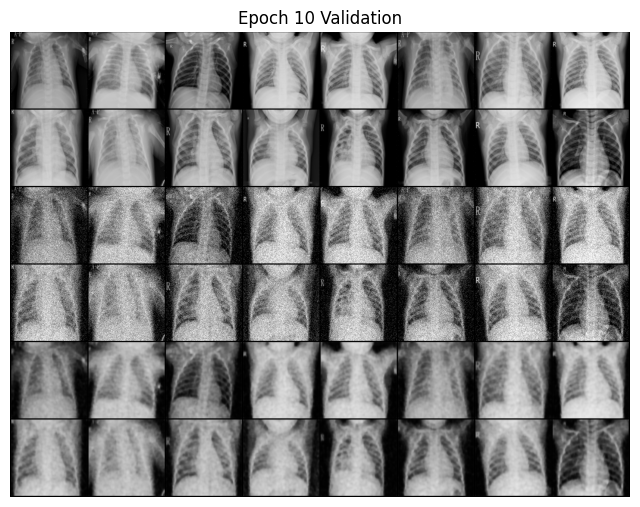

 Saved unet model at epoch 10 with val loss 0.0038


In [13]:
#Training and validation loop
#for each epoch, train,update weights, then vlaidate.
#save the model with least validation loss as unet model.

for epoch in range(num_epochs):
        #Training 
        print("Training ")
        train= True
        model.train()
        total_train_loss = 0
        for data in train_dataloader:
            img, _ = data
            img = Variable(img)
            sigma = random.choice([0.1, 0.2, 0.3])
            noisy_img = add_noise(img, sigma=sigma)
            # ===================forward=====================
            output = model(noisy_img)
            loss = criterion(output, img)
            # ===================backward====================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            
        # ===================log========================
        
        avg_train_loss = total_train_loss / len(train_dataloader) #avergae loss per epoch
        train_losses.append(avg_train_loss) #store average loss per epoch for plotting later
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}") #print the avg loss for each epoch
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            grid = save_comparison_grid(img, noisy_img, output, epoch) #save grid of original, noisy and reconstructed images every 10 epochs
            plt.figure(figsize=(8,8))
            plt.imshow(grid.permute(1, 2, 0))
            plt.title(f"Epoch {epoch+1} Training")
            plt.axis('off')
            plt.show()
        

        ##Validation
        train=False
        model.eval()
        print("Validation ")
        total_val_loss = 0
        with torch.no_grad(): #forward pass only
            for data in val_dataloader:
                img, _ = data
                img = Variable(img)
                sigma = 0.2  #fixed noise level for validation
                noisy_img = add_noise(img, sigma=sigma)
                output = model(noisy_img)
                loss = criterion(output, img)
                total_val_loss += loss.item() 
            avg_val_loss = total_val_loss / len(val_dataloader)  
            val_losses.append(avg_val_loss)
            print(f"Epoch [{epoch+1}/{num_epochs}], val_Loss: {avg_val_loss:.4f}")
            if epoch % 10 == 0 or epoch == num_epochs - 1:
                grid = save_comparison_grid(img, noisy_img, output, epoch) #save grid of original, noisy and reconstructed images every 10 epochs
                plt.figure(figsize=(8,8))
                plt.imshow(grid.permute(1, 2, 0))
                plt.title(f"Epoch {epoch+1} Validation")
                plt.axis('off')
                plt.show()
        #save model with least validation loss as unet model
        if avg_val_loss < unet_val_loss:
            unet_val_loss = avg_val_loss
            torch.save({
            'model_state_dict': model.state_dict(),
            'unet_val_loss': unet_val_loss, 'optimizer': optimizer.state_dict(),
             }, "unet_model.pth")

            print(f" Saved unet model at epoch {epoch+1} with val loss {unet_val_loss:.4f}")
        

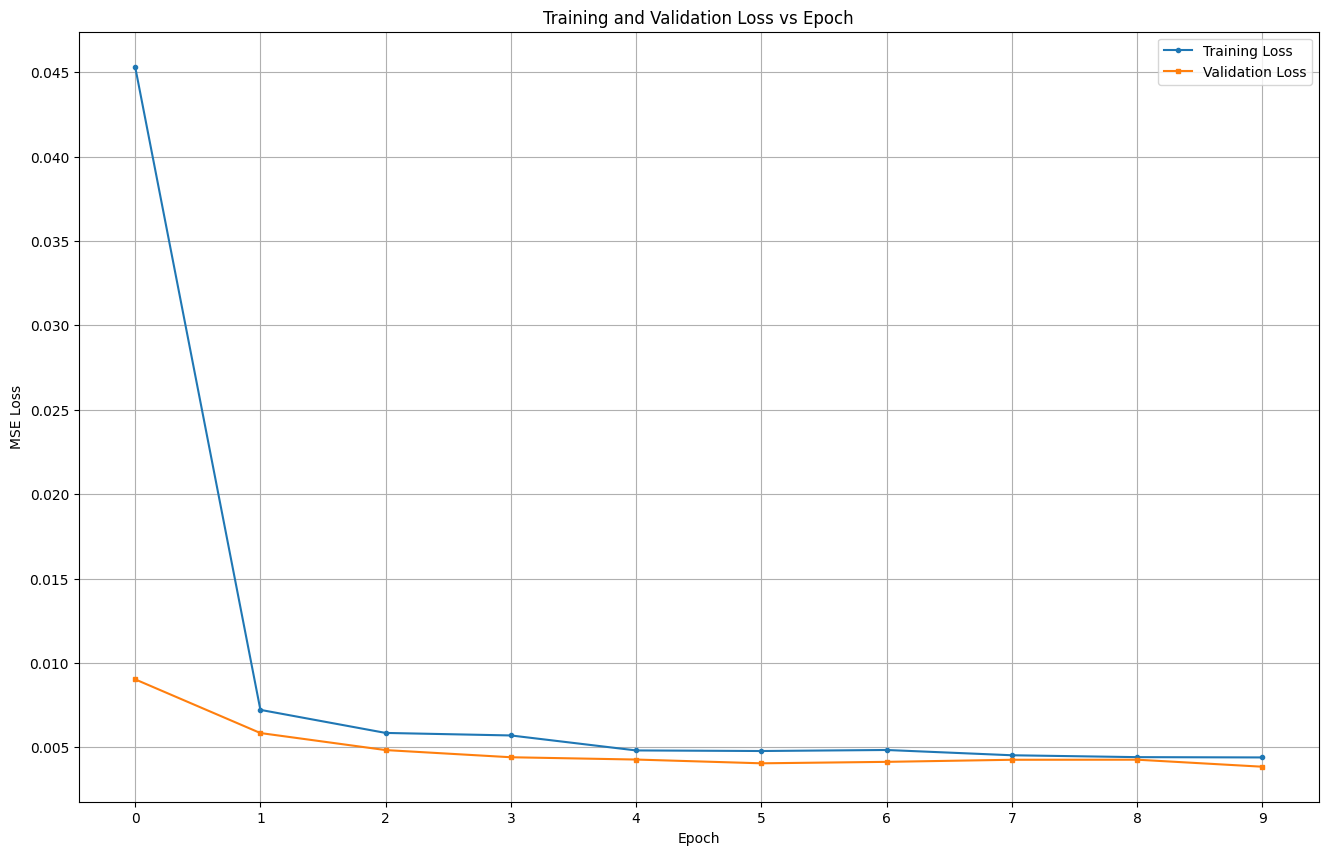

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
from datetime import datetime

# Generate timestamp string
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

plt.figure(figsize=(16,10))

# Very small markers
plt.plot(train_losses, marker='o', markersize=3, label='Training Loss')
plt.plot(val_losses, marker='s', markersize=3, label='Validation Loss')

plt.title("Training and Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

# Force x-axis ticks to step by 1
plt.xticks(np.arange(0, len(train_losses), 1))

# Control y-axis tick spacing (example: step of 0.01)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.005))

plt.legend()
plt.grid(True)

# Save with timestamped filenames
plt.savefig(f"loss_plot_{timestamp}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"loss_plot_{timestamp}.pdf", dpi=300, bbox_inches='tight')

# Show in terminal/notebook
plt.show()


In [15]:
torch.save(train_losses, train_loss_file)
print("Saved updated training loss history")
torch.save(val_losses, val_loss_file)
print("Saved updated val_loss history")

Saved updated training loss history
Saved updated val_loss history


Saved experiment_results.csv and experiment_results.xlsx


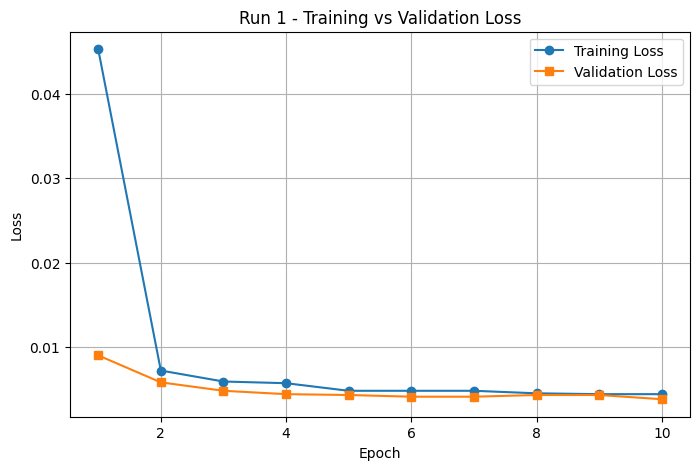

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Hardcoded data from your logs
data = {
    "Epoch": list(range(1, 11)),
    "Run1_Train": [0.0453, 0.0072, 0.0059, 0.0057, 0.0048, 0.0048, 0.0048, 0.0045, 0.0044, 0.0044],
    "Run1_Val":   [0.0090, 0.0058, 0.0048, 0.0044, 0.0043, 0.0041, 0.0041, 0.0043, 0.0043, 0.0038],
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to CSV and Excel
df.to_csv("experiment_results.csv", index=False)
df.to_excel("experiment_results.xlsx", index=False)

print("Saved experiment_results.csv and experiment_results.xlsx")

# Plot each run separately
for run in range(1, 2):
    train_col = f"Run{run}_Train"
    val_col = f"Run{run}_Val"

    plt.figure(figsize=(8,5))
    plt.plot(df["Epoch"], df[train_col], marker='o', label="Training Loss")
    plt.plot(df["Epoch"], df[val_col], marker='s', label="Validation Loss")

    plt.title(f"Run {run} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Save each plot
    plt.savefig(f"run{run}_loss_plot.png", dpi=300, bbox_inches='tight')
    plt.show()



=== Experiment Results ===
 Epoch  Run1_Train  Run1_Val
     1      0.0453    0.0090
     2      0.0072    0.0058
     3      0.0059    0.0048
     4      0.0057    0.0044
     5      0.0048    0.0043
     6      0.0048    0.0041
     7      0.0048    0.0041
     8      0.0045    0.0043
     9      0.0044    0.0043
    10      0.0044    0.0038


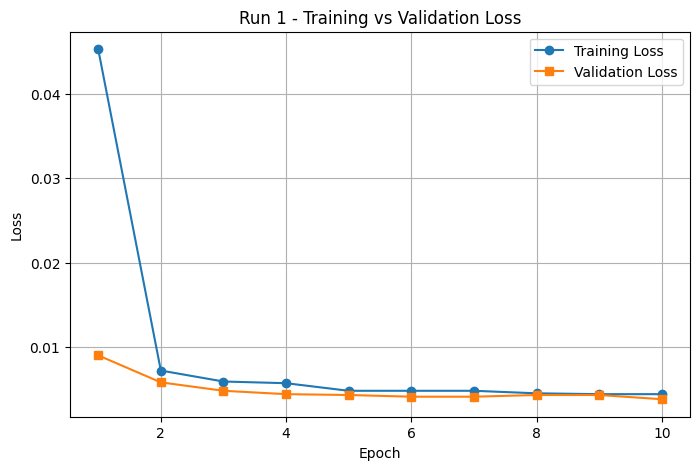

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Hardcoded data from your logs
data = {
    "Epoch": list(range(1, 11)),
    "Run1_Train": [0.0453, 0.0072, 0.0059, 0.0057, 0.0048, 0.0048, 0.0048, 0.0045, 0.0044, 0.0044],
    "Run1_Val":   [0.0090, 0.0058, 0.0048, 0.0044, 0.0043, 0.0041, 0.0041, 0.0043, 0.0043, 0.0038],
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Show the table in terminal instead of saving
print("\n=== Experiment Results ===")
print(df.to_string(index=False))

# Plot each run separately
for run in range(1, 2):
    train_col = f"Run{run}_Train"
    val_col = f"Run{run}_Val"

    plt.figure(figsize=(8,5))
    plt.plot(df["Epoch"], df[train_col], marker='o', label="Training Loss")
    plt.plot(df["Epoch"], df[val_col], marker='s', label="Validation Loss")

    plt.title(f"Run {run} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()
